In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

In [ ]:
print(data.head())
print(data.describe())
print(data.info)

  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127  

In [ ]:
print(data.isnull().sum())

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features_to_scale = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

In [ ]:
scaled_data = scaler.fit_transform(data[[
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]])

scaled_df = pd.DataFrame(scaled_data, columns=[
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
])
print(scaled_df)

      daily_screen_time_hours  social_media_hours  gaming_hours  \
0                    0.025556            0.274545        0.2225   
1                    0.232222            0.601818        0.5600   
2                    0.340000            0.156364        0.9575   
3                    0.536667            0.972727        0.3775   
4                    0.773333            0.985455        0.8550   
...                       ...                 ...           ...   
7495                 0.761111            0.227273        0.7825   
7496                 0.296667            0.332727        0.6900   
7497                 0.776667            0.565455        0.2725   
7498                 0.637778            0.198182        0.0175   
7499                 0.782222            0.890909        0.1825   

      work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             0.736364     0.677778               0.991304           0.842424   
1             0.716364     0.7022

In [ ]:
data['sm_addiction_score'] = (
    scaled_df['social_media_hours'] * 3.0 +
    scaled_df['notifications_per_day'] * 1.5 +
    scaled_df['app_opens_per_day'] * 1.0 +
    scaled_df['daily_screen_time_hours'] * 1.0 +
    scaled_df['weekend_screen_time'] * 0.8 -
    scaled_df['sleep_hours'] * 1.0 -
    scaled_df['work_study_hours'] * 0.5
)
print(data['sm_addiction_score'])

0       2.158808
1       2.236086
2       1.616675
3       4.375837
4       5.289445
          ...   
7495    3.617361
7496    1.572337
7497    3.527161
7498    2.000058
7499    4.784224
Name: sm_addiction_score, Length: 7500, dtype: float64


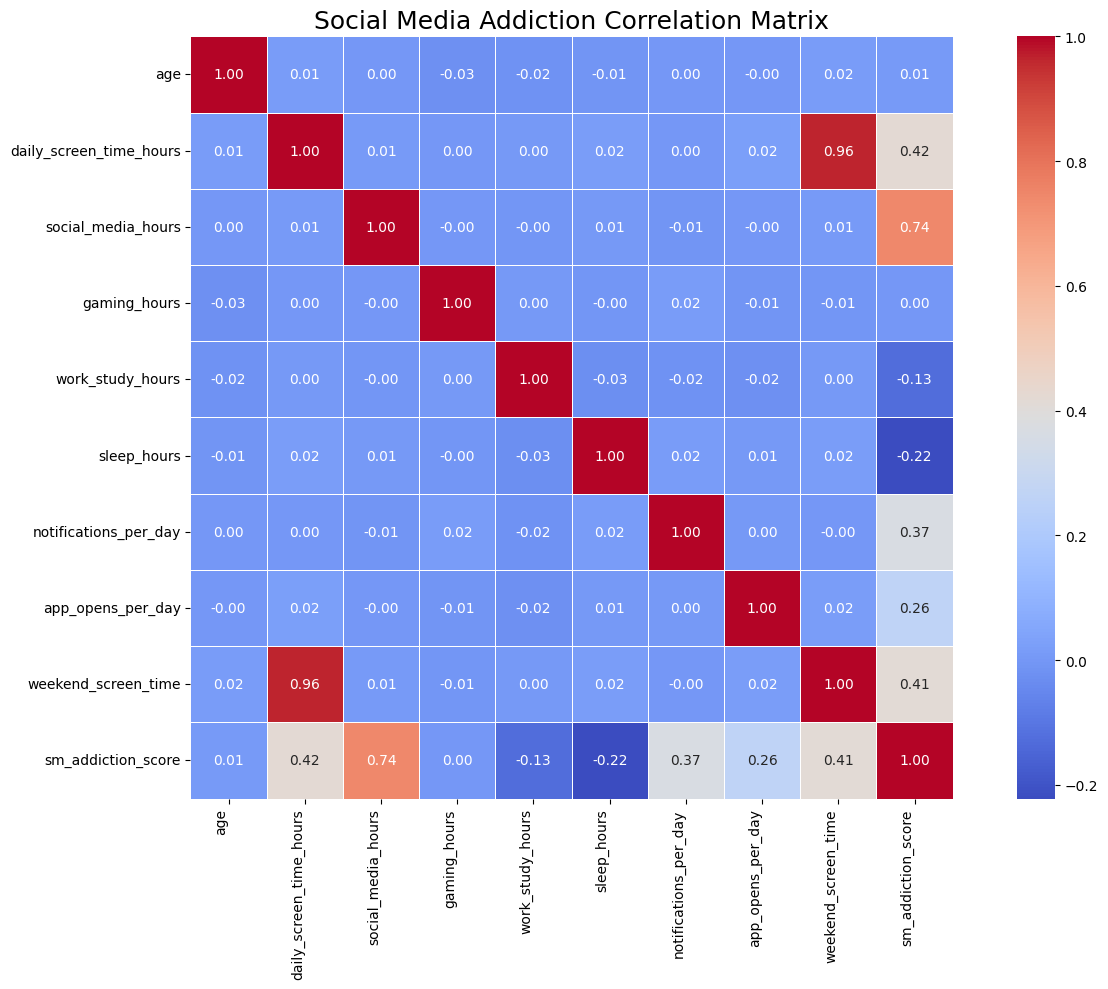

In [ ]:
plt.style.use('default')
corr_matrix = data.drop(columns=['addicted_label']) \
                  .select_dtypes(include=['number']) \
                  .corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',linewidths=0.5, square=True)
plt.title("Social Media Addiction Correlation Matrix", fontsize=18)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

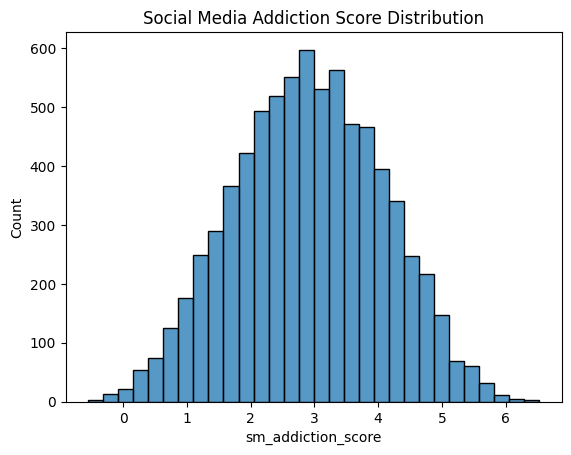

In [ ]:
sns.histplot(data['sm_addiction_score'], bins=30)
plt.title("Social Media Addiction Score Distribution")
plt.show()

In [ ]:
data['sm_addiction_label'] = pd.cut(
    data['sm_addiction_score'],
    bins=3,
    labels=[0, 1, 2]
)

print(data['sm_addiction_label'])

0       1
1       1
2       0
3       2
4       2
       ..
7495    1
7496    0
7497    1
7498    1
7499    2
Name: sm_addiction_label, Length: 7500, dtype: category
Categories (3, int64): [0 < 1 < 2]


In [ ]:
print(data['sm_addiction_label'].isnull().sum())
data = data.dropna(subset=['sm_addiction_label'])

0


In [ ]:
print(data['sm_addiction_label'].value_counts())

sm_addiction_label
1    5003
0    1366
2    1131
Name: count, dtype: int64


In [ ]:
data = data.drop(columns=['addicted_label','addiction_level'])
print(data)

     transaction_id user_id  age  gender  daily_screen_time_hours  \
0          TXN00001  U00001   21    Male                     3.23   
1          TXN00002  U00002   24   Other                     5.09   
2          TXN00003  U00003   31   Other                     6.06   
3          TXN00004  U00004   32   Other                     7.83   
4          TXN00005  U00005   25    Male                     9.96   
...             ...     ...  ...     ...                      ...   
7495       TXN07496  U07496   26   Other                     9.85   
7496       TXN07497  U07497   35    Male                     5.67   
7497       TXN07498  U07498   22  Female                     9.99   
7498       TXN07499  U07499   23    Male                     8.74   
7499       TXN07500  U07500   27  Female                    10.04   

      social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                   2.01          0.89              4.55         7.55   
1                   3.81 

In [ ]:
X = scaled_df[[
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]]

y = data['sm_addiction_label']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

Logistic Regression Accuracy:  0.922
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       278
           1       1.00      0.88      0.94       976
           2       0.81      1.00      0.89       246

    accuracy                           0.92      1500
   macro avg       0.88      0.96      0.91      1500
weighted avg       0.94      0.92      0.92      1500



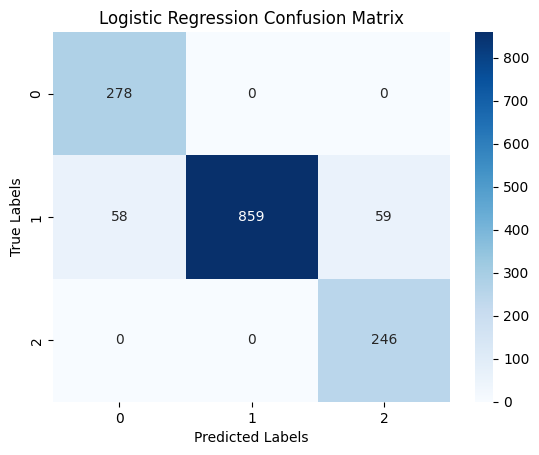

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

SVM Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       278
           1       1.00      0.90      0.95       976
           2       0.82      1.00      0.90       246

    accuracy                           0.93      1500
   macro avg       0.89      0.96      0.92      1500
weighted avg       0.94      0.93      0.93      1500



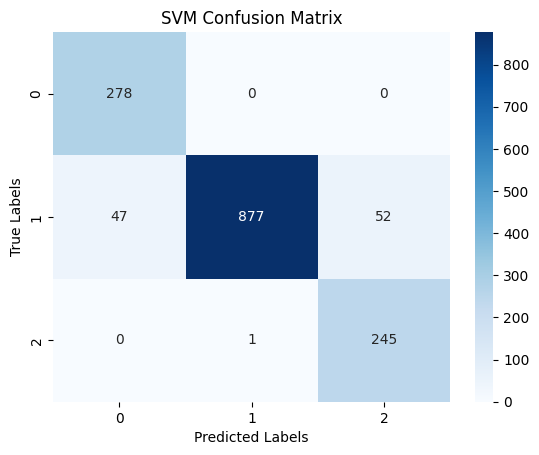

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVM Confusion Matrix")
plt.show()

Random Forest Accuracy: 0.9006666666666666
              precision    recall  f1-score   support

           0       0.95      0.74      0.83       278
           1       0.88      0.98      0.93       976
           2       0.97      0.75      0.85       246

    accuracy                           0.90      1500
   macro avg       0.93      0.83      0.87      1500
weighted avg       0.91      0.90      0.90      1500



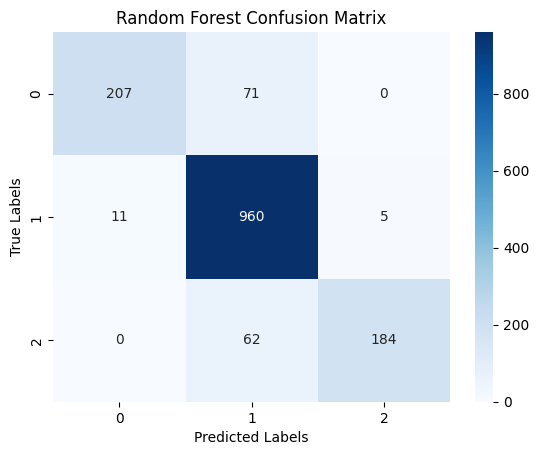

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Random Forest Confusion Matrix")
plt.show()

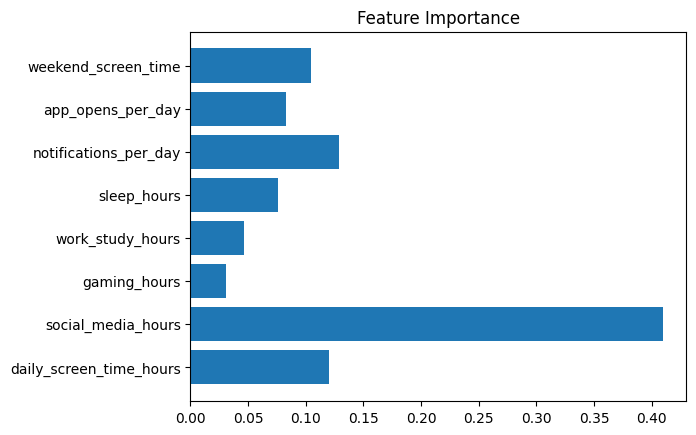

In [ ]:
importance = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
plt.barh(X.columns, importance)
plt.title('Feature Importance')
plt.show()

Logistic Regression: 0.922
SVM: 0.9333333333333333
Random Forest: 0.9006666666666666


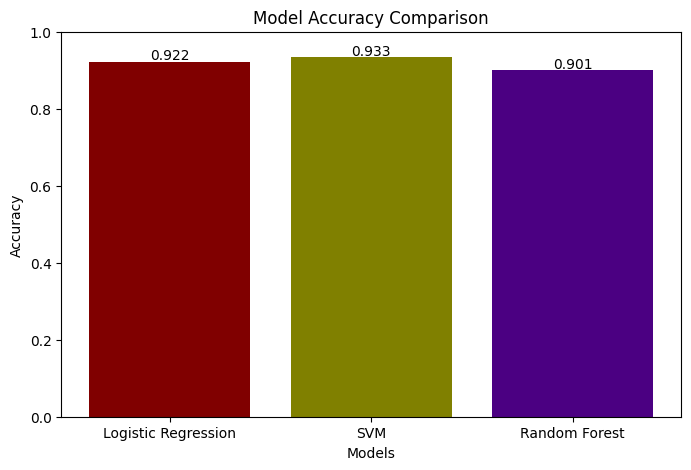

In [ ]:
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

models = ['Logistic Regression', 'SVM', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred),accuracy_score(y_test, y_pred_svm),accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color = ['maroon', 'olive', 'indigo'])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.005,
             f'{yval:.3f}',
             ha='center')


plt.ylim(0,1)
plt.show()

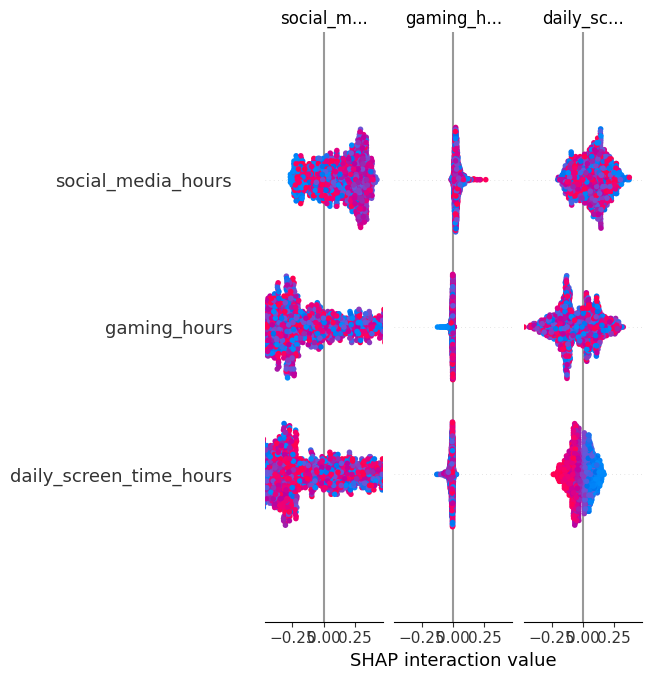

In [ ]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  class_names=["Low Risk", "Medium Risk", "High Risk"],
                  feature_names=X_test.columns.tolist())

In [ ]:
def predict_with_explanation(new_data_scaled, prediction):

    label_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
    risk = label_map[prediction[0]]
    proba = rf_model.predict_proba(new_data_scaled)[0]
    low_prob, med_prob, high_prob = proba[0], proba[1], proba[2]

    print(f"\n{'='*45}")
    print(f"  SOCIAL MEDIA RISK ASSESSMENT")
    print(f"{'='*45}")
    print(f"  Current Risk Level : {risk}")
    print(f"  Confidence         : {max(proba)*100:.1f}%")
    '''print(f"\n  Risk Probability Breakdown:")
    print(f"Low Risk    : {low_prob*100:.1f}%")
    print(f"Medium Risk : {med_prob*100:.1f}%")
    print(f"High Risk   : {high_prob*100:.1f}%")'''
    print(f"\n  Risk Probability Breakdown:")
    bar_styles = ["Low Risk   ", "Medium Risk", "High Risk  "]
    for i, bar_label in enumerate(bar_styles):
      pct = proba[i] * 100
      filled = int(pct / 5)
      bar = "█" * filled + "░" * (20 - filled)
      print(f"  {bar_label} {bar} {pct:.1f}%")
    print(f"\n  PREVENTIVE INSIGHT:")
    if prediction[0] == 0:
        if med_prob > 0.25:
            print("   Currently Low Risk but showing early Medium Risk signals.")
            print(" → Monitor social media hours and notification frequency.")
        else:
            print("   Healthy usage patterns detected. Keep it up!")

    elif prediction[0] == 1:
        if high_prob > 0.30:
            print(".  Medium Risk with strong High Risk tendency detected.")
            print(" → Immediate attention needed before patterns worsen.")
            '''print("\n")'''
        else:
            print("    Moderate risk detected. Early intervention recommended before it becomes severe.")
            print("  → Consider reducing late night usage and notifications.")
            '''print("\n")'''

    elif prediction[0] == 2:
        print("   High Risk detected. Harmful patterns are already forming.")
        print(" → Strongly recommend digital detox and usage limits.")
        '''print("\n")'''

    print(f"\n  KEY FACTORS DRIVING YOUR RISK:")
    shap_vals = explainer.shap_values(new_data_scaled_df)
    if isinstance(shap_vals, list):
        class_shap = shap_vals[2][0]
    else:
        class_shap = shap_vals[0, :, 2]

    feature_impacts = list(zip(X.columns, class_shap))
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)

    for feature, impact in feature_impacts[:4]:
        direction = "↑ increases" if impact > 0 else "↓ reduces"
        print(f"  • {feature.replace('_', ' ').title()} {direction} your risk (impact: {abs(impact):.3f})")

    print(f"{'='*45}\n")

SOCIAL MEDIA ADDICTION PREDICTOR

Let's begin social media addiction risk assessment!

Enter social media hours: 9
Enter notifications per day: 449
Enter app opens per day: 19
Enter sleep hours: 6
Enter daily screen time hours: 12
Enter gaming hours: 2
Enter work study hours: 1
Enter weekend screen time: 20

  📊 MULTI-MODEL CONSENSUS
  Random Forest:         High Risk
  SVM:                   High Risk
  Logistic Regression:   High Risk

  SOCIAL MEDIA RISK ASSESSMENT
  Current Risk Level : High Risk
  Confidence         : 81.0%

  Risk Probability Breakdown:
  Low Risk    ░░░░░░░░░░░░░░░░░░░░ 0.0%
  Medium Risk ███░░░░░░░░░░░░░░░░░ 19.0%
  High Risk   ████████████████░░░░ 81.0%

  PREVENTIVE INSIGHT:
   High Risk detected. Harmful patterns are already forming.
 → Strongly recommend digital detox and usage limits.

  KEY FACTORS DRIVING YOUR RISK:
  • Social Media Hours ↑ increases your risk (impact: 0.310)
  • Notifications Per Day ↑ increases your risk (impact: 0.122)
  • App Opens P

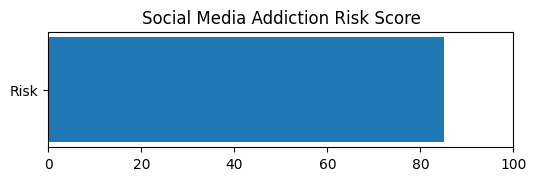

In [ ]:
print("="*60)
print("SOCIAL MEDIA ADDICTION PREDICTOR")
print("="*60)
print("\nLet's begin social media addiction risk assessment!\n")
sm = float(input("Enter social media hours: "))
notif = int(input("Enter notifications per day: "))
apps = int(input("Enter app opens per day: "))
sleep = float(input("Enter sleep hours: "))
dsh = float(input("Enter daily screen time hours: "))
gh = float(input("Enter gaming hours: "))
wsh = float(input("Enter work study hours: "))
wesh = float(input("Enter weekend screen time: "))

new_data = pd.DataFrame([{
    'daily_screen_time_hours': dsh,
    'social_media_hours': sm,
    'gaming_hours': gh,
    'work_study_hours': wsh,
    'sleep_hours': sleep,
    'notifications_per_day': notif,
    'app_opens_per_day': apps,
    'weekend_screen_time': wesh
}])

new_data_scaled = scaler.transform(new_data)
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=X.columns)
prediction = rf_model.predict(new_data_scaled_df)
prediction_2 = svm_model.predict(new_data_scaled_df)
prediction_3 = model.predict(new_data_scaled_df)

label_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}

print("\n" + "="*60)
print("  📊 MULTI-MODEL CONSENSUS")
print("="*60)
print(f"  Random Forest:         {label_map[prediction[0]]}")
print(f"  SVM:                   {label_map[prediction_2[0]]}")
print(f"  Logistic Regression:   {label_map[prediction_3[0]]}")

predict_with_explanation(new_data_scaled_df, prediction)
risk_score_map = {0: 15, 1: 50, 2: 85}
risk_score = risk_score_map[int(rf_model.predict(new_data_scaled_df)[0])]
plt.figure(figsize=(6, 1.5))
plt.barh(["Risk"], [risk_score])
plt.xlim(0, 100)
plt.title("Social Media Addiction Risk Score")
plt.show()